# Work in progress: Batched LLM inference with Hugging Face Transformers

Note: This notebook is a work in progress.

* TK - this notebook builds off of the LLM fine-tuning tutorial - https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial 

In [1]:
import time

print(f"Last updated: {time.ctime()}")

Last updated: Tue Apr  7 01:58:23 2026


## Bonus: Speeding up our model with batched inference

UPTOHERE TODO:

- Get the code working end to end
- Add intro explaining this requires knowledge from the previous notebook
- Break this notebook into sections
    - Goal
    - Intro
    - Step by step code to reproduce the workflow
    - Where to go next

--

Right now our model only inferences on one sample at a time but as is the case with many machine learning models, we could perform inference on multiple samples (also referred to as a batch) to significantly improve throughout.

In batched inference mode, your model performs predictions on X number of samples at once, this can dramatically improve sample throughput.

The number of samples you can predict on at once will depend on a few factors: 

* The size of your model (e.g. if your model is quite large, it may only be able to predict on 1 sample at time)
* The size of your compute VRAM (e.g. if your compute VRAM is already saturated, add multiple samples at a time may result in errors)
* The size of your samples (if one of your samples is 100x the size of others, this may cause errors with batched inference)

To find an optimal batch size for our setup, we can run an experiment:

* Loop through different batch sizes and measure the throughput for each batch size.
    * Why do we do this?
        * It's hard to tell the ideal batch size ahead of time.
        * So we experiment from say 1, 2, 4, 8, 16, 32, 64 batch sizes and see which performs best.
        * Just because we may get a speed up from using batch size 8, doesn't mean 64 will be better. 

In [2]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

def sample_to_conversation(sample):
    return {
        "messages": [
            {"role": "user", "content": sample["sequence"]}, # Load the sequence from the dataset
            {"role": "system", "content": sample["gpt-oss-120b-label-condensed"]} # Load the gpt-oss-120b generated label
        ]
    }

# Map our sample_to_conversation function to dataset 
dataset = dataset.map(sample_to_conversation,
                      batched=False)

# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=False,
                                            seed=42)

# Number #1 rule in machine learning
# Always train on the train set and test on the test set
# This gives us an indication of how our model will perform in the real world
dataset

[INFO] Number of samples in the dataset: 1420


Map:   0%|          | 0/1420 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'messages'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'messages'],
        num_rows: 284
    })
})

## TK - Load the model

In [3]:
# Load the fine-tuned model and see how it goes
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

print(f"[INFO] Loading in model from: {MODEL_ID}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_ID,
)

# Load trained model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_ID,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);

# Check our loaded model (it's the same architecture as before except this time with updated weights)
loaded_model

[INFO] Loading in model from: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


/home/mrdbourke/miniforge3/envs/ai/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

In [4]:
from transformers import pipeline

loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

Device set to use cuda:0


In [5]:
# Step 1: Need to turn our samples into batches (e.g. lists of samples)
print(f"[INFO] Formatting test samples into list prompts...")
test_input_prompts = [
    loaded_model_pipeline.tokenizer.apply_chat_template(
        item["messages"][:1],
        tokenize=False,
        add_generation_prompt=True
    )
    for item in dataset["test"]
]
print(f"[INFO] Number of test sample prompts: {len(test_input_prompts)}")
test_input_prompts[0]

[INFO] Formatting test samples into list prompts...
[INFO] Number of test sample prompts: 284


'<bos><start_of_turn>user\nLiving Planet Goat Milk Whole Milk, 1 Litre, GMO Free, Australian Dairy, 8.75g Protein Per Serve, Good Source of Calcium.<end_of_turn>\n<start_of_turn>model\n'

## TK - Run batch predictions with manual batching

In [6]:
# Step 2: Need to perform batched inference and time each step
import time
from tqdm.auto import tqdm

all_outputs = []

# Let's write a list of batch sizes to test
chunk_sizes_to_test = [1, 4, 8, 16, 32, 64, 128]
timing_dict = {}

# Loop through each batch size and time the inference
for CHUNK_SIZE in chunk_sizes_to_test:
    print(f"[INFO] Making predictions with batch size: {CHUNK_SIZE}")
    start_time = time.time()

    for chunk_number in tqdm(range(round(len(test_input_prompts) / CHUNK_SIZE))):
        batched_inputs = test_input_prompts[(CHUNK_SIZE * chunk_number): CHUNK_SIZE * (chunk_number + 1)]
        batched_outputs = loaded_model_pipeline(text_inputs=batched_inputs,
                                                batch_size=CHUNK_SIZE,
                                                max_new_tokens=256,
                                                disable_compile=True)
        
        all_outputs += batched_outputs
    
    end_time = time.time()
    total_time = end_time - start_time
    timing_dict[CHUNK_SIZE] = total_time
    print()
    print(f"[INFO] Total time for batch size {CHUNK_SIZE}: {total_time:.2f}s")
    print("="*80 + "\n\n")

[INFO] Making predictions with batch size: 1


  0%|          | 0/284 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[INFO] Total time for batch size 1: 140.96s


[INFO] Making predictions with batch size: 4


  0%|          | 0/71 [00:00<?, ?it/s]

...


[INFO] Total time for batch size 32: 29.05s


[INFO] Making predictions with batch size: 64


  0%|          | 0/4 [00:00<?, ?it/s]


[INFO] Total time for batch size 64: 26.58s


[INFO] Making predictions with batch size: 128


  0%|          | 0/2 [00:00<?, ?it/s]


[INFO] Total time for batch size 128: 48.55s




In [8]:
# TK - What does all_outputs do?
print(len(all_outputs))

1932


## TK - Run batch predictions with `pipeline`'s automatic batching

In [7]:
import time

chunk_sizes_to_test = [1, 4, 8, 16, 32, 64, 128]
timing_dict = {}

for batch_size in chunk_sizes_to_test:
    print(f"[INFO] Running with batch_size={batch_size}")
    start_time = time.time()

    outputs = loaded_model_pipeline(
        test_input_prompts,
        batch_size=batch_size,
        max_new_tokens=256,
    )

    elapsed = time.time() - start_time
    timing_dict[batch_size] = elapsed
    print(f"[INFO] batch_size={batch_size}: {elapsed:.2f}s | {len(test_input_prompts)/elapsed:.1f} samples/s\n")

print(timing_dict)

[INFO] Running with batch_size=1
[INFO] batch_size=1: 141.51s | 2.0 samples/s

[INFO] Running with batch_size=4
[INFO] batch_size=4: 50.78s | 5.6 samples/s

[INFO] Running with batch_size=8
[INFO] batch_size=8: 31.32s | 9.1 samples/s

[INFO] Running with batch_size=16
[INFO] batch_size=16: 23.60s | 12.0 samples/s

[INFO] Running with batch_size=32
[INFO] batch_size=32: 31.65s | 9.0 samples/s

[INFO] Running with batch_size=64
[INFO] batch_size=64: 27.02s | 10.5 samples/s

[INFO] Running with batch_size=128
[INFO] batch_size=128: 49.46s | 5.7 samples/s

{1: 141.50579595565796, 4: 50.78420948982239, 8: 31.3158278465271, 16: 23.59804058074951, 32: 31.647218704223633, 64: 27.02465510368347, 128: 49.4646852016449}


In [12]:
batch_size

128

## TK - Run with KeyDataset

In [14]:
# Run in the same script/notebook where loaded_model_pipeline, test_input_prompts, and ds are defined
import time
from datasets import Dataset
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm

chunk_sizes_to_test = [1, 4, 8, 16, 32, 64, 128]
timing_dict = {}
all_outputs = {}

ds = Dataset.from_dict({"text": test_input_prompts})

for batch_size in chunk_sizes_to_test:
    print(f"[INFO] Running with batch_size={batch_size}")
    start_time = time.time()

    outputs = []
    for out in tqdm(
        loaded_model_pipeline(KeyDataset(ds, "text"), batch_size=batch_size, max_new_tokens=256),
        total=len(test_input_prompts),
        desc=f"batch_size={batch_size}",
    ):
        outputs.append(out)

    elapsed = time.time() - start_time
    timing_dict[batch_size] = elapsed
    all_outputs[batch_size] = outputs
    print(f"[INFO] batch_size={batch_size}: {elapsed:.2f}s | {len(test_input_prompts)/elapsed:.1f} samples/s\n")

# --- Verification: compare all batch sizes against batch_size=1 as baseline ---
baseline_size = chunk_sizes_to_test[0]
baseline_outputs = all_outputs[baseline_size]

print(f"{'Batch Size':<12} {'Length Match':<14} {'Outputs Match':<16} {'Time (s)':<10} {'Speedup vs bs=1'}")
print("=" * 70)

for batch_size in chunk_sizes_to_test:
    outputs = all_outputs[batch_size]
    len_match = len(outputs) == len(baseline_outputs)
    outputs_match = outputs == baseline_outputs
    speedup = timing_dict[baseline_size] / timing_dict[batch_size]

    print(f"{batch_size:<12} {str(len_match):<14} {str(outputs_match):<16} {timing_dict[batch_size]:<10.2f} {speedup:.2f}x")

[INFO] Running with batch_size=1


batch_size=1:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] batch_size=1: 138.49s | 2.1 samples/s

[INFO] Running with batch_size=4


batch_size=4:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] batch_size=4: 52.81s | 5.4 samples/s

[INFO] Running with batch_size=8


...

[INFO] batch_size=32: 23.01s | 12.3 samples/s

[INFO] Running with batch_size=64


batch_size=64:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] batch_size=64: 28.02s | 10.1 samples/s

[INFO] Running with batch_size=128


batch_size=128:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] batch_size=128: 40.81s | 7.0 samples/s

Batch Size   Length Match   Outputs Match    Time (s)   Speedup vs bs=1
1            True           True             138.49     1.00x
4            True           False            52.81      2.62x
8            True           False            32.97      4.20x
16           True           False            25.95      5.34x
32           True           False            23.01      6.02x
64           True           False            28.02      4.94x
128          True           False            40.81      3.39x


## TK - Compare the results of batch (token size)

In [18]:
# Run in the same script/notebook, after the benchmarking loop above
from difflib import SequenceMatcher

def extract_generated_text(output):
    """Extract the generated text string from a pipeline output.
    Adjust the key access depending on your pipeline's output format."""
    if isinstance(output, list):
        return output[0]["generated_text"]
    return output["generated_text"]

def token_similarity(text_a, text_b):
    """Simple token-level overlap: proportion of matching tokens."""
    tokens_a = text_a.split()
    tokens_b = text_b.split()
    matcher = SequenceMatcher(None, tokens_a, tokens_b)
    return matcher.ratio()  # 0.0 to 1.0

# Compare all batch sizes against batch_size=1
baseline_size = chunk_sizes_to_test[0]
baseline_texts = [extract_generated_text(o) for o in all_outputs[baseline_size]]

print(f"{'Batch Size':<12} {'Length Match':<14} {'Avg Token Sim':<16} {'Time (s)':<10} {'Speedup vs bs=1'}")
print("=" * 70)

for batch_size in chunk_sizes_to_test:
    outputs = all_outputs[batch_size]
    candidate_texts = [extract_generated_text(o) for o in outputs]

    len_match = len(candidate_texts) == len(baseline_texts)

    similarities = [
        token_similarity(base, cand)
        for base, cand in zip(baseline_texts, candidate_texts)
    ]
    avg_sim = sum(similarities) / len(similarities) * 100

    speedup = timing_dict[baseline_size] / timing_dict[batch_size]

    sim_str = f"{avg_sim:.2f}%"
    print(f"{batch_size:<12} {str(len_match):<14} {sim_str:<16} {timing_dict[batch_size]:<10.2f} {speedup:.2f}x")

Batch Size   Length Match   Avg Token Sim    Time (s)   Speedup vs bs=1
1            True           100.00%          138.49     1.00x
4            True           99.08%           52.81      2.62x
8            True           99.20%           32.97      4.20x
16           True           99.17%           25.95      5.34x
32           True           99.13%           23.01      6.02x
64           True           99.25%           28.02      4.94x
128          True           99.24%           40.81      3.39x


## TK - Compare the results of batching (speed wise)

Batched inference complete! Let's make a plot comparing different batch sizes.

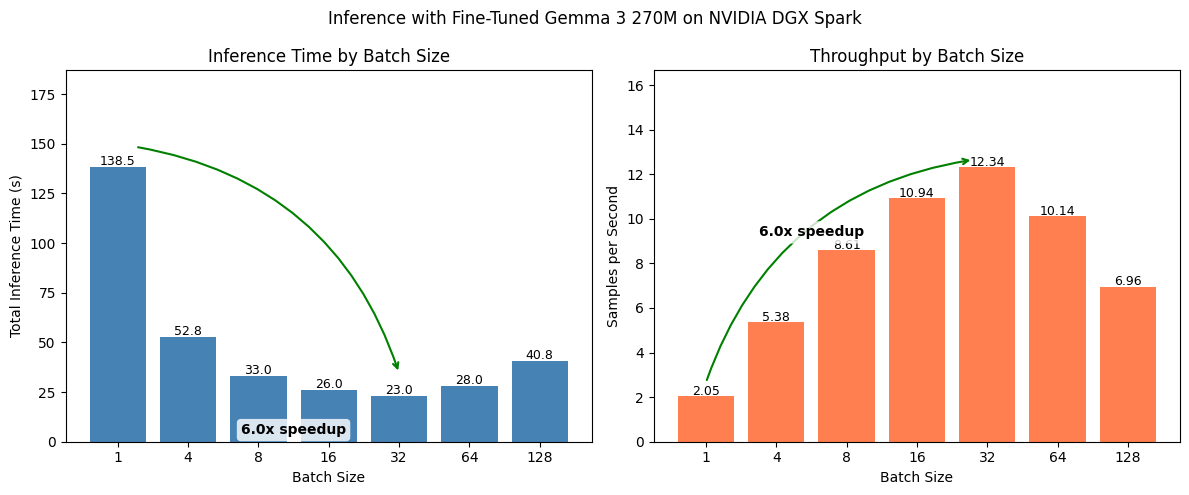

In [16]:
import matplotlib.pyplot as plt

# Data
data = timing_dict

total_samples = len(dataset["test"])

batch_sizes = list(data.keys())
inference_times = list(data.values())
samples_per_second = [total_samples / time for bs, time in data.items()]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: Total Inference Time ---
ax1.bar([str(bs) for bs in batch_sizes], inference_times, color='steelblue')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Total Inference Time (s)')
ax1.set_title('Inference Time by Batch Size')

for i, v in enumerate(inference_times):
    ax1.text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# --- ARROW LOGIC (Left) ---
# 1. Identify Start (Slowest) and End (Fastest)
start_val = max(inference_times)
end_val = min(inference_times)
start_idx = inference_times.index(start_val)
end_idx = inference_times.index(end_val)

speedup = start_val / end_val

# 2. Draw Arrow (No Text)
# connectionstyle "rad=-0.3" arcs the arrow upwards
ax1.annotate("",
             xy=(end_idx, end_val+(0.5*end_val)),
             xytext=(start_idx+0.25, start_val+10),
             arrowprops=dict(arrowstyle="->", color='green', lw=1.5, connectionstyle="arc3,rad=-0.3"))

# 3. Place Text at Midpoint
mid_x = (start_idx + end_idx) / 2
# Place text slightly above the highest point of the two bars
text_y = max(start_val, end_val) + (max(inference_times) * 0.1)

ax1.text(mid_x+0.5, text_y-150, f"{speedup:.1f}x speedup",
         ha='center', va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax1.set_ylim(0, max(inference_times) * 1.35) # Increase headroom for text


# --- Right plot: Samples per Second ---
ax2.bar([str(bs) for bs in batch_sizes], samples_per_second, color='coral')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Samples per Second')
ax2.set_title('Throughput by Batch Size')

for i, v in enumerate(samples_per_second):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# --- ARROW LOGIC (Right) ---
# 1. Identify Start (Slowest) and End (Fastest)
start_val_t = min(samples_per_second)
end_val_t = max(samples_per_second)
start_idx_t = samples_per_second.index(start_val_t)
end_idx_t = samples_per_second.index(end_val_t)

speedup_t = end_val_t / start_val_t

# 2. Draw Arrow (No Text)
ax2.annotate("",
             xy=(end_idx_t-(0.05*end_idx_t), end_val_t+(0.025*end_val_t)),
             xytext=(start_idx_t, start_val_t+0.6),
             arrowprops=dict(arrowstyle="->", color='green', lw=1.5, connectionstyle="arc3,rad=-0.3"))

# 3. Place Text at Midpoint
mid_x_t = (start_idx_t + end_idx_t) / 2
text_y_t = max(start_val_t, end_val_t) + (max(samples_per_second) * 0.1)

ax2.text(mid_x_t-0.5, text_y_t-4.5, f"{speedup_t:.1f}x speedup",
         ha='center', va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax2.set_ylim(0, max(samples_per_second) * 1.35) # Increase headroom

plt.suptitle("Inference with Fine-Tuned Gemma 3 270M on NVIDIA DGX Spark")
plt.tight_layout()
plt.savefig('inference_benchmark.png', dpi=150)
plt.show()

We get a 4-6x speedup when using batches!

At 10 samples per second, that means we can inference on ~800k samples in a day.

In [17]:
samples_per_second = round(len(dataset["test"]) / min(timing_dict.values()), 2)
seconds_in_a_day = 86_400
samples_per_day = seconds_in_a_day * samples_per_second

print(f"[INFO] Number of samples per second: {samples_per_second} | Number of samples per day: {samples_per_day}")

[INFO] Number of samples per second: 12.34 | Number of samples per day: 1066176.0


## TK - Extensions

TK - next: vllm inference for faster modelling